# LST (Large-Sized Telescope)

LST-1 North-like configuration with hexagonal camera.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope, show_camera, show_sensor_chain, show_telescope

## Load telescope and camera

In [2]:
telescope = Telescope.from_yaml(
    "../../configs/CTAO/LST_1_North_like.yaml",
    n_samples=256,
    key=jax.random.key(42),
)
camera = Camera.from_yaml("../../configs/CTAO/LSTCam.yaml")

E0713 16:07:26.626992  127030 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0713 16:07:26.627114  127031 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0713 16:07:26.627196  127032 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## 3D scene

In [3]:
scene = show_telescope(telescope, camera=camera)
scene.show(viewer="jupyter")

In [4]:
scene = show_sensor_chain(camera)
scene.show(viewer="jupyter")

## Star field image

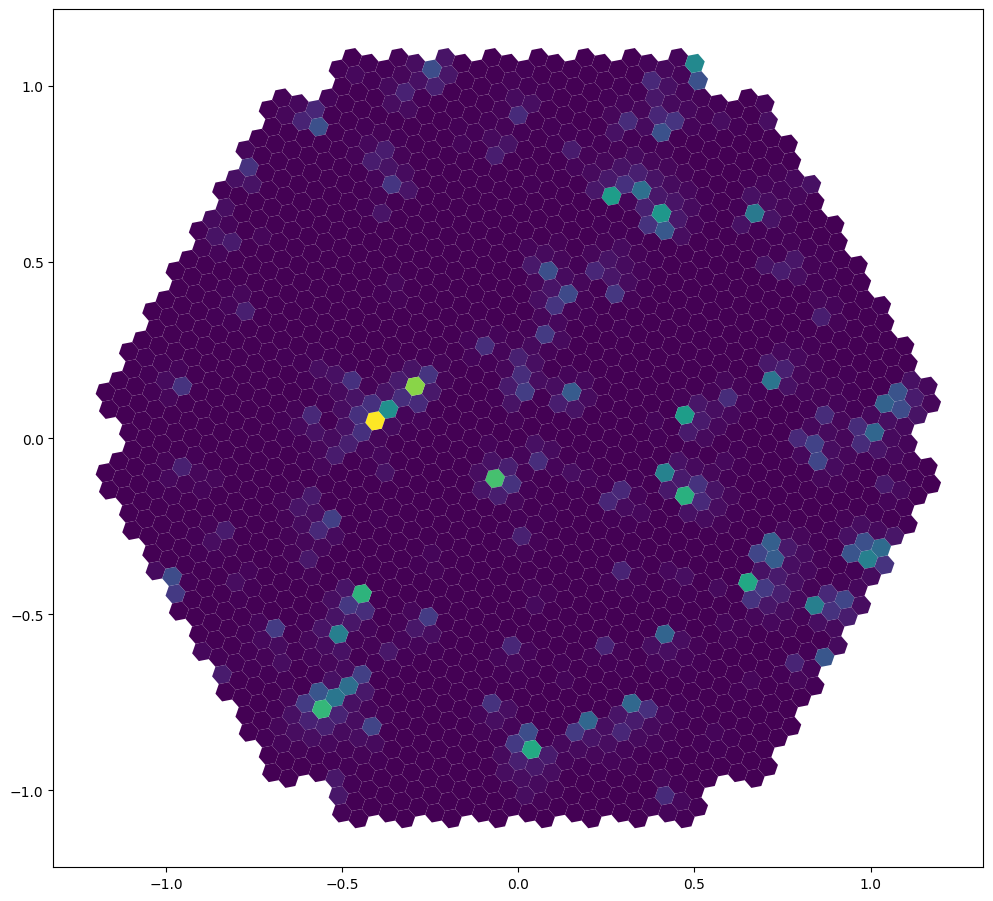

In [5]:
n_stars = 1000
key = jax.random.key(42)
key1, key2 = jax.random.split(key)

fov_deg = 4.3
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

f_stars = 10 ** (-10 * jax.random.uniform(jax.random.key(4242), shape=(len(stars),)))

rays = telescope.render(stars, f_stars, source_type="parallel")
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_camera(image, camera.sensor_groups[0], ax=ax)

## Bokeh from a finite-distance point source

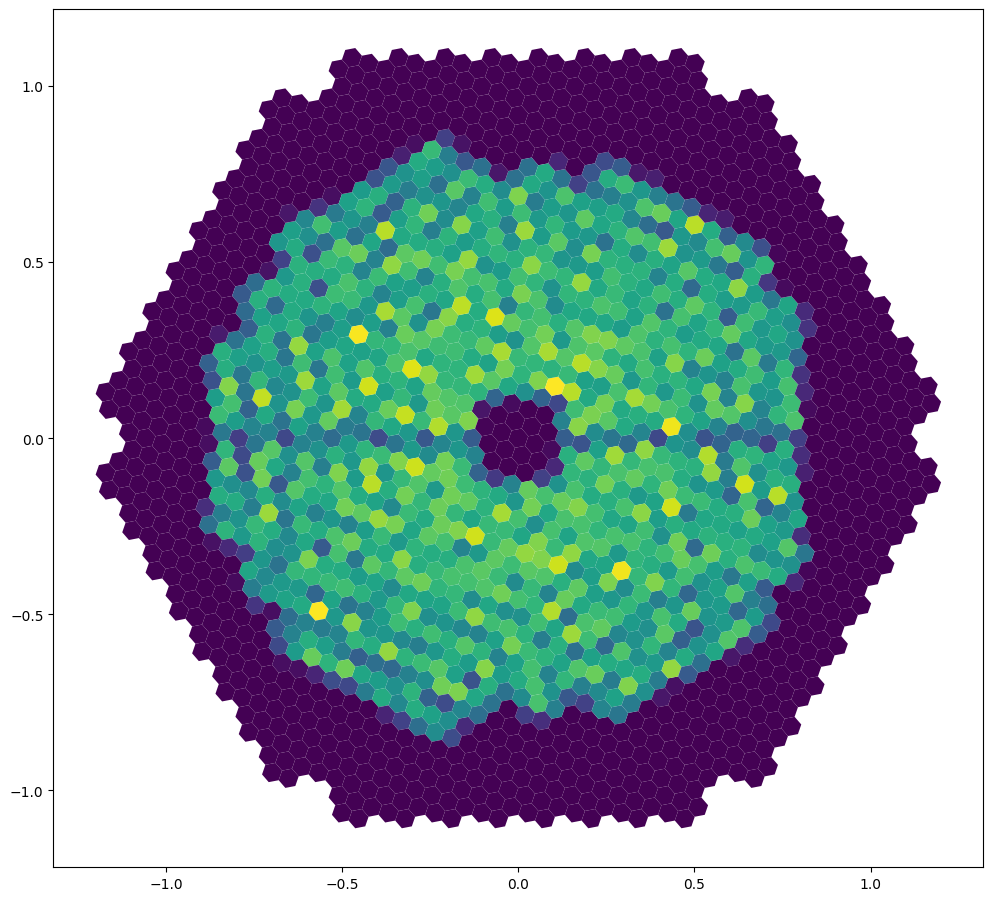

In [6]:
N_points = 1
key1, key2 = jax.random.split(jax.random.key(45))

x = jax.random.uniform(key1, N_points, minval=-0.1, maxval=0.1)
y = jax.random.uniform(key2, N_points, minval=-0.1, maxval=0.1)
z = jnp.ones(N_points) * 400

points = jnp.array([x, y, z]).T
f_points = jnp.ones(len(points))

rays = telescope.render(points, f_points, source_type="point")
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_camera(image, camera.sensor_groups[0], ax=ax)

## Spot diagram from explicit ray geometry

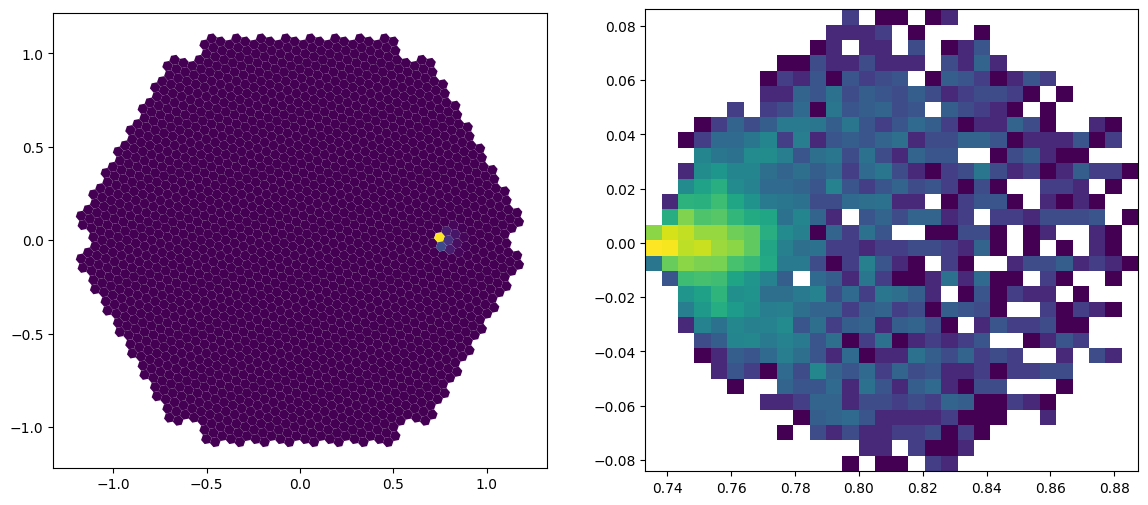

In [7]:
from iactrace.analysis import FlatFocalPlane

n_rays = 10000
key1, key2 = jax.random.split(jax.random.key(123))

r = 12.0 * jnp.sqrt(jax.random.uniform(key1, (n_rays,)))
theta = jax.random.uniform(key2, (n_rays,)) * 2 * jnp.pi
ray_origins = jnp.stack(
    [r * jnp.cos(theta), r * jnp.sin(theta), jnp.ones(n_rays) * 40.0],
    axis=1,
)

tilt_angle = 1.5 * jnp.pi / 180
ray_directions = jnp.broadcast_to(
    jnp.array([jnp.sin(tilt_angle), 0.0, -jnp.cos(tilt_angle)]),
    (n_rays, 3),
)
ray_values = jnp.ones(n_rays)

rays = telescope.trace(ray_origins, ray_directions, ray_values)
image = camera.image(rays)

focal_plane = FlatFocalPlane()
hits = focal_plane.intersect(rays)

fig, ax = plt.subplots(ncols=2, figsize=(14, 6))
show_camera(image, camera.sensor_groups[0], ax=ax[0])
h2 = ax[1].hist2d(
    hits.xy_local[hits.alive, 0],
    hits.xy_local[hits.alive, 1],
    bins=30,
    norm="log",
)